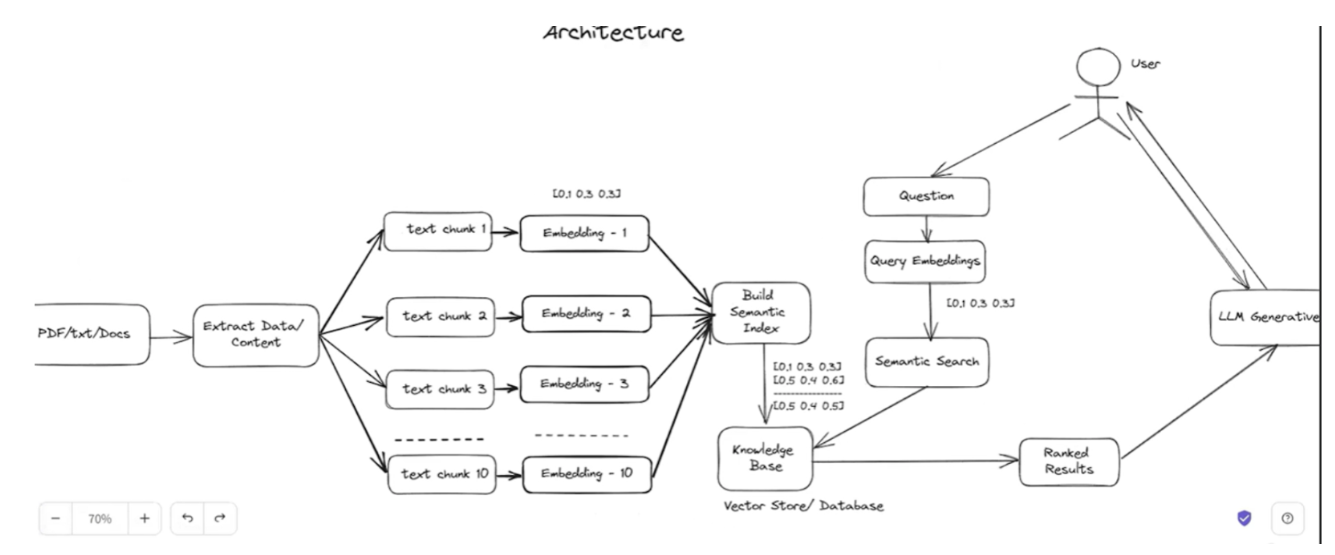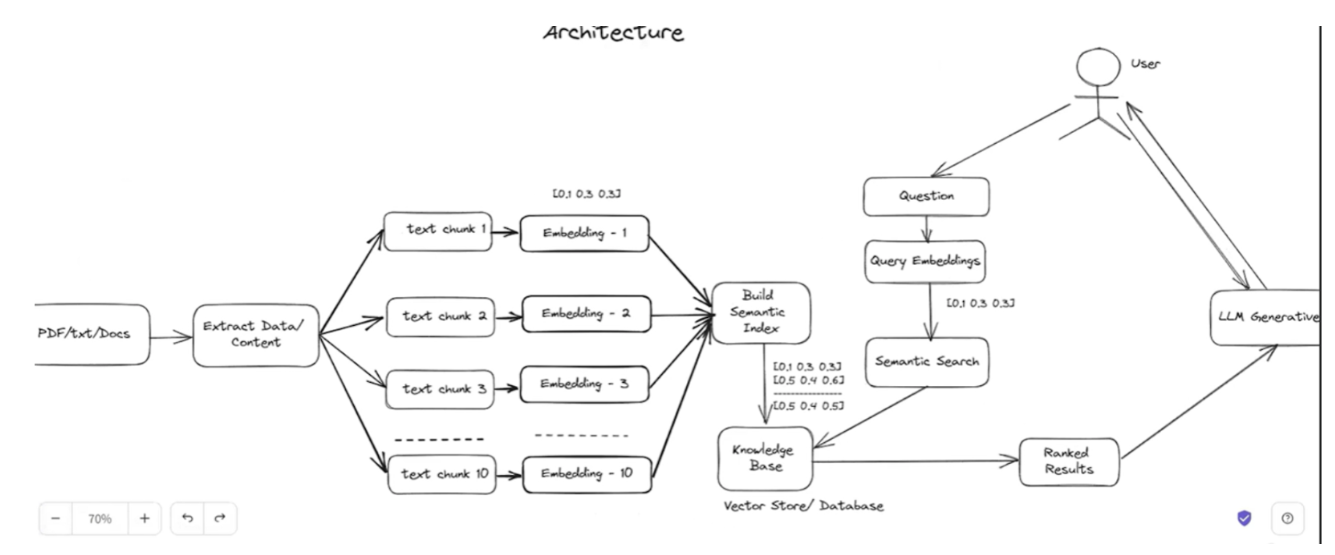

In [4]:
corpus_of_documents = [
    "Take a leisurely walk in the park and enjoy the fresh air.",
    "Visit a local museum and discover something new."
    "Attend a live music concert and feel the rhythm."
    "Go for a hike and admire the natural scenery."
    "Have a picnic with friends and share some laughs."
    "Explore a new cuisine by dining at an ethnic restaurant."
    "Take a yoga class and stretch your body and mind."
    "Join a local sports league and enjoy some friendly competition.",
    "Attend a workshop or lecture on a topic you're interested in."
    "Visit an amusement park and ride the roller coasters."
]

In [6]:
corpus_of_documents

['Take a leisurely walk in the park and enjoy the fresh air.',
 'Visit a local museum and discover something new.Attend a live music concert and feel the rhythm.Go for a hike and admire the natural scenery.Have a picnic with friends and share some laughs.Explore a new cuisine by dining at an ethnic restaurant.Take a yoga class and stretch your body and mind.Join a local sports league and enjoy some friendly competition.',
 "Attend a workshop or lecture on a topic you're interested in.Visit an amusement park and ride the roller coasters."]

In [38]:
user_query= "i am an indian and i live in india"

In [39]:
document= "india is a country for the indians and for everyone" 

In [40]:
from collections import Counter
import math

In [41]:
query_tokens= user_query.lower().split(" ")

In [42]:
documents_tokens= document.lower().split(" ")

In [43]:
query_tokens


['i', 'am', 'an', 'indian', 'and', 'i', 'live', 'in', 'india']

In [44]:
documents_tokens


['india',
 'is',
 'a',
 'country',
 'for',
 'the',
 'indians',
 'and',
 'for',
 'everyone']

In [45]:
query_Counter= Counter(query_tokens)

In [46]:
document_Counter= Counter(documents_tokens)

In [47]:
document_Counter

Counter({'india': 1,
         'is': 1,
         'a': 1,
         'country': 1,
         'for': 2,
         'the': 1,
         'indians': 1,
         'and': 1,
         'everyone': 1})

In [48]:
query_Counter

Counter({'i': 2,
         'am': 1,
         'an': 1,
         'indian': 1,
         'and': 1,
         'live': 1,
         'in': 1,
         'india': 1})

In [49]:
lst=[]
for tokens in query_Counter.keys():
    lst.append(query_Counter[tokens])

In [50]:

lst

[2, 1, 1, 1, 1, 1, 1, 1]

In [56]:
mylist=[]
for token in query_Counter.keys() & document_Counter.keys():
    mylist.append(query_Counter[token] * document_Counter[token])

In [57]:
mylist

[1, 1]

In [67]:
dot_product= sum(mylist)

In [63]:
 query_magnitude= math.sqrt(sum(query_Counter[token] ** 2 for token in query_Counter))

In [64]:
query_magnitude

3.3166247903554

In [65]:
document_magnitude= math.sqrt(sum(document_Counter[token] ** 2 for token in document_Counter))

In [66]:
document_magnitude

3.4641016151377544

In [70]:
similarity= (dot_product)/(query_magnitude*document_magnitude)

In [71]:
similarity

0.17407765595569785

In [72]:
user_query= "is yoga good for health"

In [73]:
document= "yoga is good for living healthy lifestyle"

In [74]:
def cosine_similarity(query, document):
    # Tokenize and convert to lowercase
    query_tokens = query.lower().split(" ")
    document_tokens = document.lower().split(" ")

    # Create Counters for query and document
    query_counter = Counter(query_tokens)
    document_counter = Counter(document_tokens)

    # Calculate dot product
    dot_product = sum(query_counter[token] * document_counter[token] for token in query_counter.keys() & document_counter.keys())

    # Calculate magnitudes
    query_magnitude = math.sqrt(sum(query_counter[token] ** 2 for token in query_counter))
    document_magnitude = math.sqrt(sum(document_counter[token] ** 2 for token in document_counter))

    # Calculate cosine similarity
    similarity = dot_product / (query_magnitude * document_magnitude) if query_magnitude * document_magnitude != 0 else 0

    return similarity

In [75]:
cosine_similarity(user_query,document)

0.6761234037828131

In [81]:
def return_response(query, corpus):
    similarities = []
    for doc in corpus:
        similarity = cosine_similarity(query, doc)
        similarities.append(similarity)
    return corpus_of_documents[similarities.index(max(similarities))]

In [82]:
corpus_of_documents

['Take a leisurely walk in the park and enjoy the fresh air.',
 'Visit a local museum and discover something new.Attend a live music concert and feel the rhythm.Go for a hike and admire the natural scenery.Have a picnic with friends and share some laughs.Explore a new cuisine by dining at an ethnic restaurant.Take a yoga class and stretch your body and mind.Join a local sports league and enjoy some friendly competition.',
 "Attend a workshop or lecture on a topic you're interested in.Visit an amusement park and ride the roller coasters."]

In [85]:
query="i like fresh air."

In [86]:
return_response(query,corpus_of_documents)

'Take a leisurely walk in the park and enjoy the fresh air.'

In [87]:
user_input="i like to do yoga"

In [88]:
relevant_document=return_response(user_input,corpus_of_documents)

In [89]:
relevant_document

'Visit a local museum and discover something new.Attend a live music concert and feel the rhythm.Go for a hike and admire the natural scenery.Have a picnic with friends and share some laughs.Explore a new cuisine by dining at an ethnic restaurant.Take a yoga class and stretch your body and mind.Join a local sports league and enjoy some friendly competition.'

In [90]:
import requests
import json
full_response = []

In [91]:
full_response = []
prompt = """
You are a bot that makes recommendations for activities. You answer in very short sentences and do not include extra information.
This is the recommended activity: {relevant_document}
The user input is: {user_input}
Compile a recommendation to the user based on the recommended activity and the user input.
"""

url = 'http://localhost:11434/api/generate'


data = {
    "model": "llama2",
    "prompt": prompt.format(user_input=user_input, relevant_document=relevant_document)
}

headers = {'Content-Type': 'application/json'}

response = requests.post(url, data=json.dumps(data), headers=headers, stream=True)


try:
    for line in response.iter_lines():
        # filter out keep-alive new lines
        if line:
            decoded_line = json.loads(line.decode('utf-8'))
            # print(decoded_line['response'])  # uncomment to results, token by token
            full_response.append(decoded_line['response'])
finally:
    response.close()
    
    
print(''.join(full_response))

 Visit an ethnic restaurant and try their yoga-inspired cuisine.
